In [3]:
!pip install --upgrade setuptools
!pip install tensorflow
!pip install tensorflow-probability
!pip install transformers
!pip install datasets
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib seaborn
!pip install torch torchvision torchaudio 
!pip install nltk
!pip install wordcloud
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install --upgrade transformers
!pip install torch torchvision torchaudio
# Install all required libraries in one go
!pip install --upgrade pip
!pip install nltk imbalanced-learn transformers torch torchvision torchaudio scikit-learn matplotlib seaborn wordcloud tqdm


  Using cached typing_extensions-4.5.0-py3-none-any.whl.metadata (8.5 kB)
Using cached typing_extensions-4.5.0-py3-none-any.whl (27 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.13.2
    Uninstalling typing_extensions-4.13.2:
      Successfully uninstalled typing_extensions-4.13.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0 requires typing-extensions>=4.10.0, but you have typing-extensions 4.5.0 which is incompatible.
  Using cached typing_extensions-4.13.2-py3-none-any.whl.metadata (3.0 kB)
Using cached typing_extensions-4.13.2-py3-none-any.whl (45 kB)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.5.0
    Uninstalling typing_extensions-4.5.0:
      Successfully uninstalled typing_extensions-4.5.0
ERROR: pip's dependency resolver does not curren

In [4]:
# 1) IMPORT ALL REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils import compute_class_weight

from imblearn.over_sampling import RandomOverSampler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertModel,
    BertForSequenceClassification,
    get_scheduler
)
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm.auto import tqdm

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('vader_lexicon')

# 2) LOAD THE DATASET
file_path = "/home/jovyan/Project/Combined Data.csv"
df = pd.read_csv(file_path)


[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jovyan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [5]:

# 3) SHOW THE STRUCTURE OF DATASET
print(df.head())
print(df.info())
print(df.describe(include='all'))

   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None
          Unnamed: 0          statement  status
count   53043.000000              52681   53043
unique           NaN              51073       7
top              NaN  what do you mean?  Normal
f

In [6]:
# 4) CLEAN THE DATASET
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.drop_duplicates(inplace=True)
df.dropna(subset=['statement', 'status'], inplace=True)

lemmatizer = WordNetLemmatizer()
stops = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [w for w in text.split() if w not in stops]
    return ' '.join(lemmatizer.lemmatize(w) for w in tokens)

df['statement'] = df['statement'].apply(clean_text)

sia = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['statement'].apply(lambda t: sia.polarity_scores(t)['compound'])

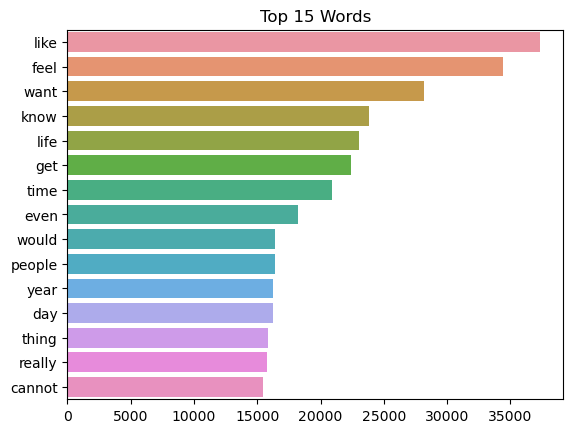

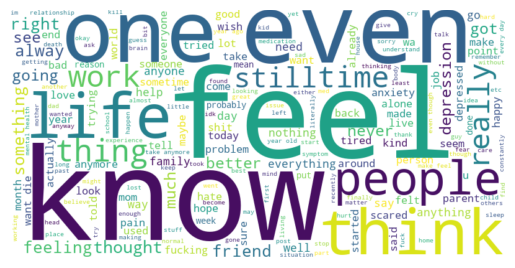

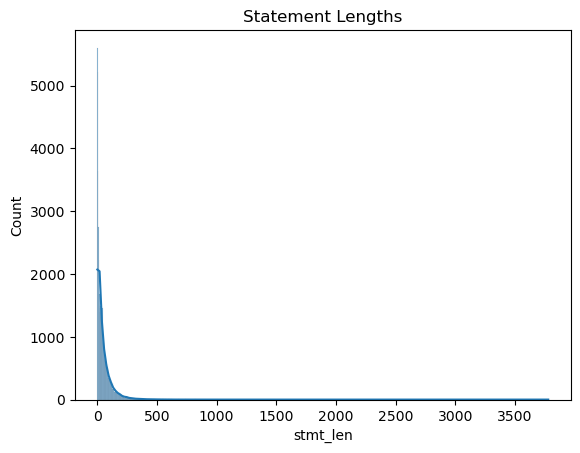

In [7]:

# 5) TEXT PROCESSING AND VISUALIZATION
all_words = ' '.join(df['statement']).split()
freq = pd.Series(all_words).value_counts().head(15)
sns.barplot(x=freq.values, y=freq.index)
plt.title("Top 15 Words"); plt.show()

wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['statement']))
plt.imshow(wc, interpolation='bilinear'); plt.axis('off'); plt.show()

df['stmt_len'] = df['statement'].apply(lambda s: len(s.split()))
sns.histplot(df['stmt_len'], kde=True)
plt.title("Statement Lengths"); plt.show()


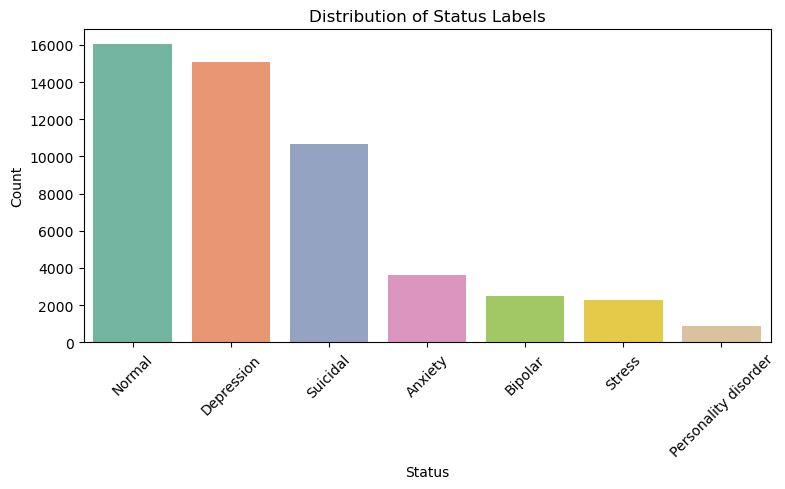

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='status', order=df['status'].value_counts().index, palette='Set2')
plt.title("Distribution of Status Labels")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
status_percent = df['status'].value_counts(normalize=True) * 100
print("Status distribution (percent):")
print(status_percent.round(2))


Status distribution (percent):
Normal                  31.39
Depression              29.54
Suicidal                20.83
Anxiety                  7.09
Bipolar                  4.89
Stress                   4.49
Personality disorder     1.75
Name: status, dtype: float64


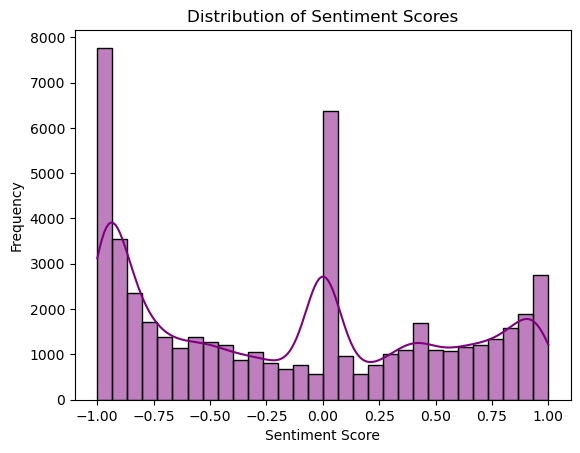

In [10]:
sns.histplot(df['sentiment_score'], kde=True, bins=30, color='purple')
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()


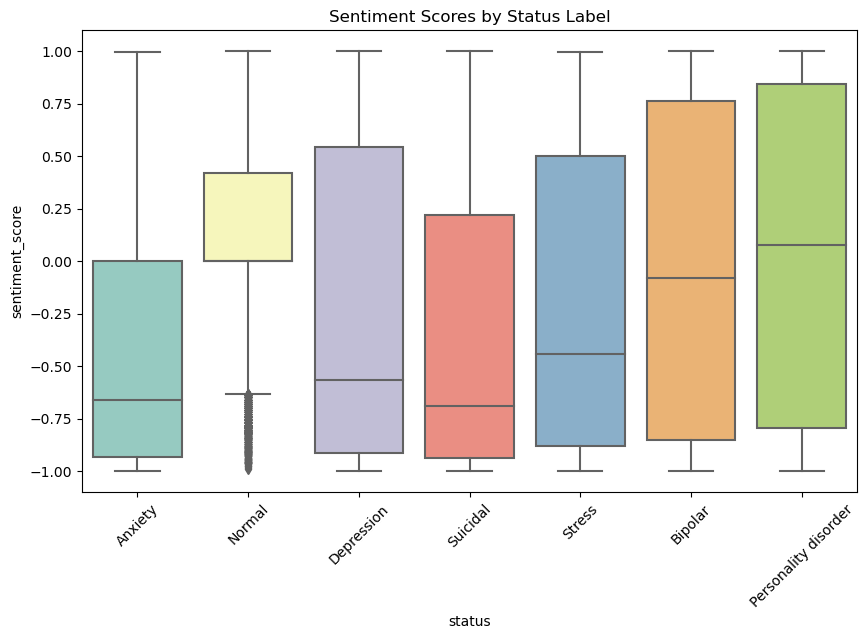

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='status', y='sentiment_score', data=df, palette='Set3')
plt.title("Sentiment Scores by Status Label")
plt.xticks(rotation=45)
plt.show()
#entiment scores by status

In [12]:
#  Before vs After Cleaning Examples
sample_df = df[['statement']].copy()
sample_df['original'] = pd.read_csv(file_path)['statement']
sample_df = sample_df.dropna().head(10)
print(sample_df[['original', 'statement']])


                                            original  \
0                                         oh my gosh   
1  trouble sleeping, confused mind, restless hear...   
2  All wrong, back off dear, forward doubt. Stay ...   
3  I've shifted my focus to something else but I'...   
4  I'm restless and restless, it's been a month n...   
5  every break, you must be nervous, like somethi...   
6  I feel scared, anxious, what can I do? And may...   
7    Have you ever felt nervous but didn't know why?   
8  I haven't slept well for 2 days, it's like I'm...   
9                 I'm really worried, I want to cry.   

                                           statement  
0                                            oh gosh  
1  trouble sleeping confused mind restless heart ...  
2  wrong back dear forward doubt stay restless re...  
3         shifted focus something else still worried  
4                   restless restless month boy mean  
5  every break must nervous like something wrong ... 

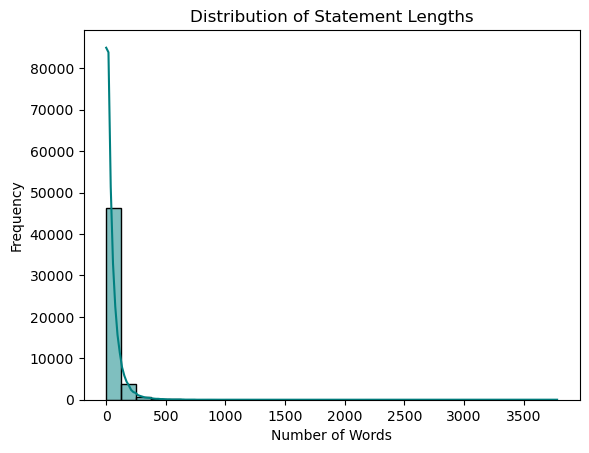

In [13]:
df['stmt_len'] = df['statement'].apply(lambda s: len(s.split()))
sns.histplot(df['stmt_len'], bins=30, kde=True, color='teal')
plt.title("Distribution of Statement Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


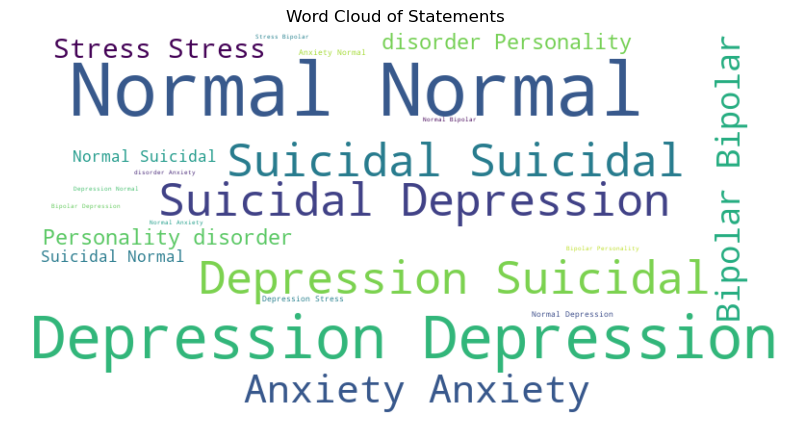

In [15]:
from wordcloud import WordCloud

text = ' '.join(df['status'])
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Statements")
plt.show()


In [16]:
# 6) LABEL ENCODING
le = LabelEncoder()
df['status_enc'] = le.fit_transform(df['status'])

# 7) SPLIT + OVERSAMPLING
X_train, X_test, y_train, y_test = train_test_split(
    df[['statement', 'sentiment_score']], 
    df['status_enc'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df['status_enc']
)

ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)
X_train = X_res['statement'].values
y_train = y_res
X_test = X_test['statement'].values
y_test = y_test.values

In [20]:
print(df.head())


                                           statement   status  \
0                                            oh gosh  Anxiety   
1  trouble sleeping confused mind restless heart ...  Anxiety   
2  wrong back dear forward doubt stay restless re...  Anxiety   
3         shifted focus something else still worried  Anxiety   
4                   restless restless month boy mean  Anxiety   

   sentiment_score  stmt_len  status_enc  
0           0.0000         2           0  
1          -0.7269         7           0  
2          -0.7351         9           0  
3          -0.2960         6           0  
4          -0.4939         5           0  


[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jovyan/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


   Unnamed: 0                                          statement   status
0           0                                         oh my gosh  Anxiety
1           1  trouble sleeping, confused mind, restless hear...  Anxiety
2           2  All wrong, back off dear, forward doubt. Stay ...  Anxiety
3           3  I've shifted my focus to something else but I'...  Anxiety
4           4  I'm restless and restless, it's been a month n...  Anxiety
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53043 non-null  int64 
 1   statement   52681 non-null  object
 2   status      53043 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB
None
          Unnamed: 0          statement  status
count   53043.000000              52681   53043
unique           NaN              51073       7
top              NaN  what do you mean?  Normal
f

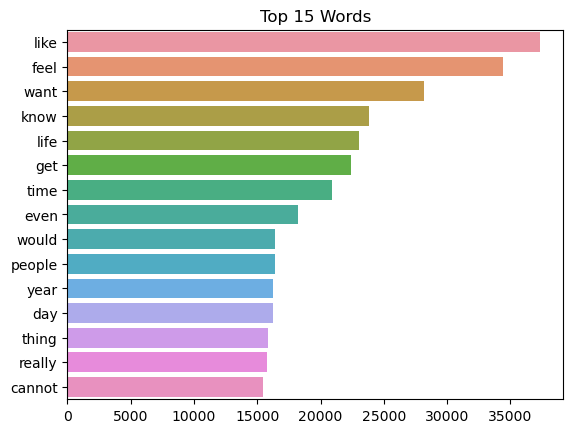

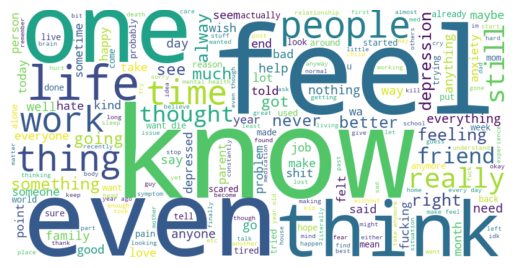

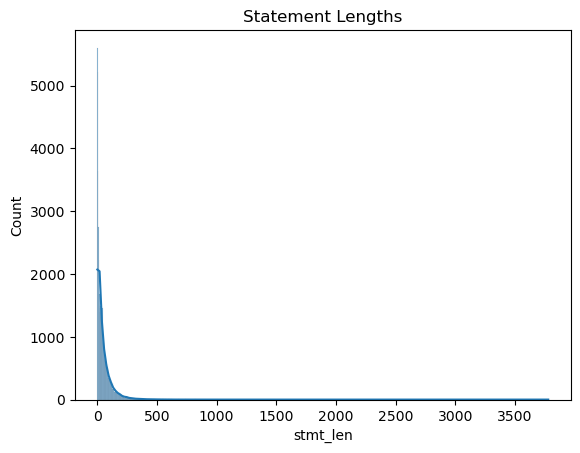

  0%|          | 0/5614 [00:00<?, ?it/s]

  0%|          | 0/639 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogReg Accuracy: 0.6240336627850083
              precision    recall  f1-score   support

           0       0.57      0.69      0.63       725
           1       0.40      0.62      0.48       500
           2       0.67      0.42      0.52      3019
           3       0.90      0.84      0.87      3208
           4       0.15      0.49      0.23       179
           5       0.28      0.54      0.37       459
           6       0.58      0.59      0.58      2129

    accuracy                           0.62     10219
   macro avg       0.51      0.60      0.53     10219
weighted avg       0.68      0.62      0.64     10219



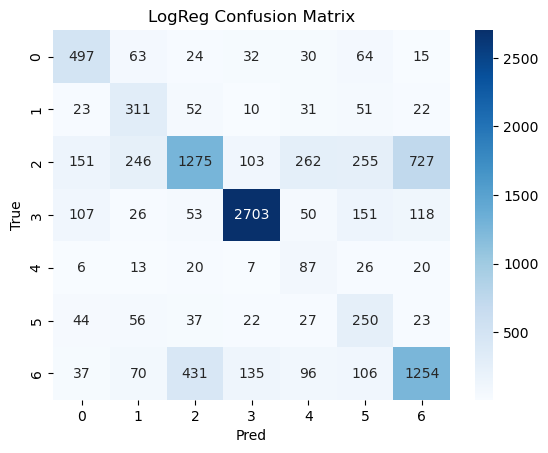

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/5614 [00:00<?, ?it/s]

Epoch 1 Loss 2923.8263


  0%|          | 0/5614 [00:00<?, ?it/s]

Epoch 2 Loss 1157.5974


  0%|          | 0/5614 [00:00<?, ?it/s]

Epoch 3 Loss 704.7606


  0%|          | 0/639 [00:00<?, ?it/s]

BERT Fine‑Tune Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       725
           1       0.84      0.74      0.78       500
           2       0.73      0.70      0.71      3019
           3       0.93      0.94      0.93      3208
           4       0.82      0.46      0.59       179
           5       0.64      0.55      0.59       459
           6       0.66      0.74      0.70      2129

    accuracy                           0.78     10219
   macro avg       0.78      0.71      0.73     10219
weighted avg       0.79      0.78      0.78     10219



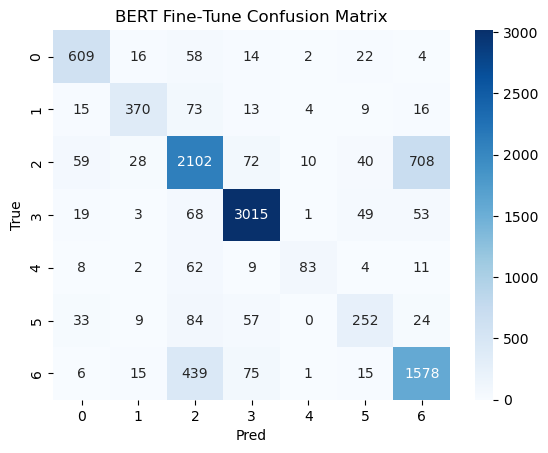

  0%|          | 0/5614 [00:00<?, ?it/s]

[LSTM] Epoch 1 Loss 2922.6682


  0%|          | 0/5614 [00:00<?, ?it/s]

[LSTM] Epoch 2 Loss 1287.1291


  0%|          | 0/5614 [00:00<?, ?it/s]

[LSTM] Epoch 3 Loss 878.8322


  0%|          | 0/639 [00:00<?, ?it/s]

BERT+LSTM Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       725
           1       0.85      0.74      0.79       500
           2       0.73      0.68      0.70      3019
           3       0.95      0.90      0.92      3208
           4       0.84      0.49      0.62       179
           5       0.54      0.63      0.59       459
           6       0.64      0.76      0.69      2129

    accuracy                           0.77     10219
   macro avg       0.76      0.72      0.73     10219
weighted avg       0.78      0.77      0.77     10219



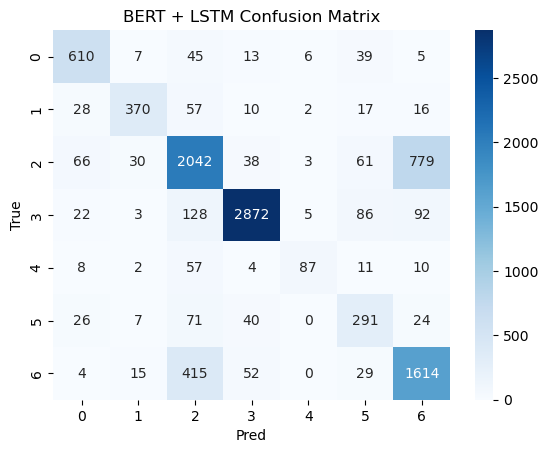

  0%|          | 0/5614 [00:00<?, ?it/s]

[CNN] Epoch 1 Loss: 2984.3122


  0%|          | 0/5614 [00:00<?, ?it/s]

[CNN] Epoch 2 Loss: 1314.4061


  0%|          | 0/5614 [00:00<?, ?it/s]

[CNN] Epoch 3 Loss: 895.7175


  0%|          | 0/639 [00:00<?, ?it/s]

BERT + CNN - Evaluation Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       725
           1       0.79      0.77      0.78       500
           2       0.76      0.57      0.65      3019
           3       0.94      0.92      0.93      3208
           4       0.84      0.45      0.59       179
           5       0.54      0.67      0.60       459
           6       0.60      0.83      0.69      2129

    accuracy                           0.76     10219
   macro avg       0.76      0.72      0.72     10219
weighted avg       0.78      0.76      0.76     10219



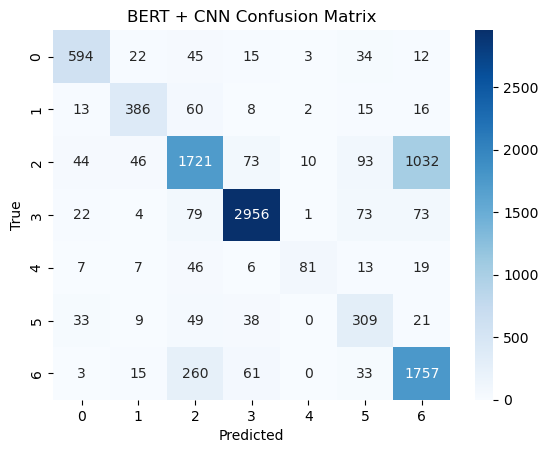

In [2]:



# 8) TOKENIZATION + DATASET

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class TextDataset(Dataset):
    def __init__(self, texts, labels, max_len=128):
        self.texts = texts
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0)
        }, torch.tensor(self.labels[idx])

train_ds = TextDataset(X_train, y_train)
test_ds  = TextDataset(X_test,  y_test)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=16)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 9) LOGISTIC REGRESSION ON BERT EMBEDDINGS

def extract_bert_features(dataloader):
    model = BertModel.from_pretrained('bert-base-uncased').to(device)
    model.eval()
    feats, labs = [], []
    with torch.no_grad():
        for (inp, lab) in tqdm(dataloader):
            inp = {k:v.to(device) for k,v in inp.items()}
            out = model(**inp).last_hidden_state[:,0,:].cpu().numpy()
            feats.append(out); labs.append(lab.numpy())
    return np.vstack(feats), np.concatenate(labs)

Xtr_feats, ytr_feats = extract_bert_features(train_loader)
Xte_feats, yte_feats = extract_bert_features(test_loader)

lr = LogisticRegression(max_iter=500)
lr.fit(Xtr_feats, ytr_feats)
y_pred = lr.predict(Xte_feats)
print("LogReg Accuracy:", accuracy_score(yte_feats, y_pred))
print(classification_report(yte_feats, y_pred))

cm = confusion_matrix(yte_feats, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("LogReg Confusion Matrix"); plt.xlabel("Pred"); plt.ylabel("True"); plt.show()

# 10) FINE-TUNED BERT CLASSIFIER

bert_clf = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=df['status_enc'].nunique()
).to(device)

opt = AdamW(bert_clf.parameters(), lr=2e-5)
epochs = 3
sched = get_scheduler(
    'linear', optimizer=opt, 
    num_warmup_steps=0, 
    num_training_steps=len(train_loader)*epochs
)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(epochs):
    bert_clf.train()
    total = 0
    for (inp, lab) in tqdm(train_loader):
        inp = {k:v.to(device) for k,v in inp.items()}
        lab = lab.to(device)
        out = bert_clf(**inp).logits
        loss = loss_fn(out, lab)
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        total += loss.item()
    print(f"Epoch {epoch+1} Loss {total:.4f}")

bert_clf.eval()
preds, trues = [], []
with torch.no_grad():
    for (inp, lab) in tqdm(test_loader):
        inp = {k:v.to(device) for k,v in inp.items()}
        lab = lab.to(device)
        out = bert_clf(**inp).logits
        preds.extend(torch.argmax(out, axis=1).cpu().numpy())
        trues.extend(lab.cpu().numpy())

print("BERT Fine‑Tune Report:")
print(classification_report(trues, preds))
cm = confusion_matrix(trues, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("BERT Fine‑Tune Confusion Matrix"); plt.xlabel("Pred"); plt.ylabel("True"); plt.show()

# 11) BERT + LSTM (Fine-tuned)

class BERT_LSTM(nn.Module):
    def __init__(self, hidden_dim=128, num_classes=7):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.lstm = nn.LSTM(
            input_size=768,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim*2, num_classes)

    def forward(self, input_ids, attention_mask):
        bert_out = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state
        lstm_out, _ = self.lstm(bert_out)
        logits = self.fc(lstm_out[:,0,:])
        return logits

model3 = BERT_LSTM(hidden_dim=128, num_classes=df['status_enc'].nunique()).to(device)
opt3 = AdamW(model3.parameters(), lr=2e-5)

for epoch in range(epochs):
    model3.train()
    total = 0
    for (inp, lab) in tqdm(train_loader):
        inp = {k:v.to(device) for k,v in inp.items()}
        lab = lab.to(device)
        out = model3(**inp)
        loss = loss_fn(out, lab)
        opt3.zero_grad(); loss.backward(); opt3.step()
        total += loss.item()
    print(f"[LSTM] Epoch {epoch+1} Loss {total:.4f}")

model3.eval()
preds3, trues3 = [], []
with torch.no_grad():
    for (inp, lab) in tqdm(test_loader):
        inp = {k:v.to(device) for k,v in inp.items()}
        out = model3(**inp)
        preds3.extend(torch.argmax(out,1).cpu().numpy())
        trues3.extend(lab.numpy())

print("BERT+LSTM Report:")
print(classification_report(trues3, preds3))
cm = confusion_matrix(trues3, preds3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("BERT + LSTM Confusion Matrix"); plt.xlabel("Pred"); plt.ylabel("True"); plt.show()

# 12) BERT + CNN (Fine-tuned)

class BERT_CNN(nn.Module):
    def __init__(self, num_classes, dropout=0.3):
        super(BERT_CNN, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.conv1 = nn.Conv1d(in_channels=768, out_channels=256, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask):
        bert_out = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        x = bert_out.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x).squeeze(2)
        x = self.dropout(x)
        return self.fc(x)

model4 = BERT_CNN(num_classes=df['status_enc'].nunique()).to(device)
opt4 = AdamW(model4.parameters(), lr=2e-5)

for epoch in range(epochs):
    model4.train()
    total_loss = 0
    for (inp, lab) in tqdm(train_loader):
        inp = {k:v.to(device) for k,v in inp.items()}
        lab = lab.to(device)
        out = model4(inp['input_ids'], inp['attention_mask'])
        loss = loss_fn(out, lab)
        opt4.zero_grad(); loss.backward(); opt4.step()
        total_loss += loss.item()
    print(f"[CNN] Epoch {epoch + 1} Loss: {total_loss:.4f}")

model4.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for (inp, lab) in tqdm(test_loader):
        inp = {k:v.to(device) for k,v in inp.items()}
        out = model4(inp['input_ids'], inp['attention_mask'])
        test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        test_labels.extend(lab.cpu().numpy())

print("BERT + CNN - Evaluation Report:")
print(classification_report(test_labels, test_preds))
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("BERT + CNN Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()
